# Импорты и общие настройки

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
from pathlib import Path
import json
from dataclasses import dataclass
import math
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

SEED = 42
DATASET = "S12-hw-dataset.csv"

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.mps.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cpu')
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
print('device:', device)
print('torch:', torch.__version__)
print('pandas',pd.__version__)
print('numpy',np.__version__)
print('sklearn',sklearn.__version__)

device: cpu
torch: 2.10.0
pandas 3.0.1
numpy 2.4.3
sklearn 1.8.0


# Подготовка артефактов

In [2]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
runs = []
def eval_run(
    eid,
    dataset,
    seed,
    split_summary,
    window_size,
    horizon,
    model_summary,
    features_summary,
    scaler,
    optimizer,
    lr,
    epochs_trained,
    best_val_mae,
    best_val_rmse,
    best_val_mape,
    test_mae,
    test_rmse,
    test_mape,
    notes,
    task = "forecasting"
):
    runs.append({
        "experiment_id":eid,
        "task":task,
        "dataset":dataset,
        "seed":seed,
        "split_summary":split_summary,
        "windows_size":window_size,
        "horizon":horizon,
        "model_summary":model_summary,
        "features_summary":features_summary,
        "scaler":scaler,
        "optimizer":optimizer,
        "lr":lr,
        "epochs_trained":epochs_trained,
        "best_val_mae":best_val_mae,
        "best_val_rmse":best_val_rmse,
        "best_val_mape":best_val_mape,
        "test_mae":test_mae,
        "test_rmse":test_rmse,
        "test_mape":test_mape,
        "notes":notes,
    })

# Данные и первичный анализ

In [3]:
df = pd.read_csv('S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
# Конвертировать в datetime
df["date"] = pd.to_datetime(df["date"])

In [5]:
# Отсортировать по дате
df.sort_values(by="date")

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [6]:
# Диапазон дат, число наблюдений
display(df.describe(include="all").T)

,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:30:00,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


In [7]:
# Пропуски
for column in df.columns:
    if df[column].isna().mean()*100 != 0:
        print(f"Доля пропусков в колонке {column}: {df[column].isna().mean()*100:.2f}% ")
        print(df[df[column].isna()])
    else:
        print(f"В колонке {column} не найдены пропуски :(")

В колонке date не найдены пропуски :(
В колонке target не найдены пропуски :(


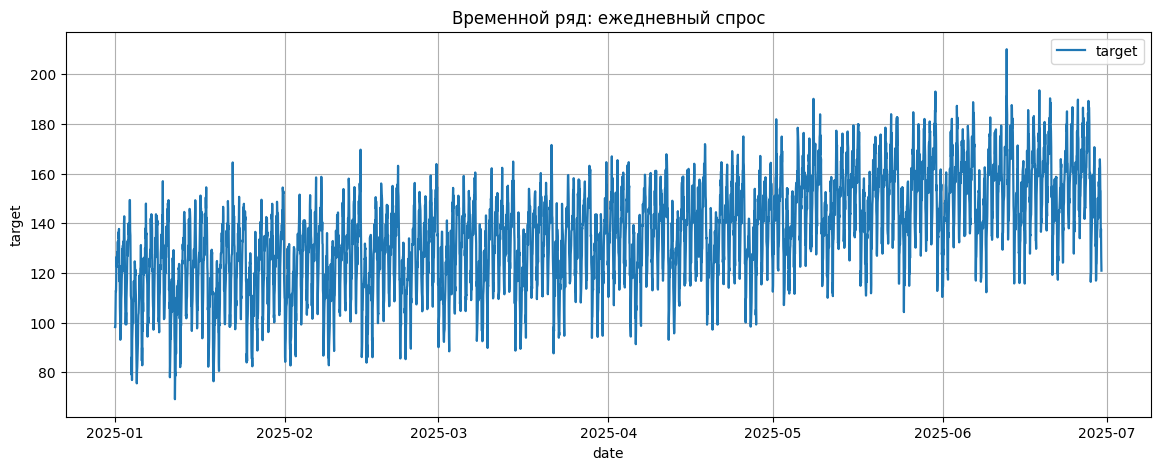

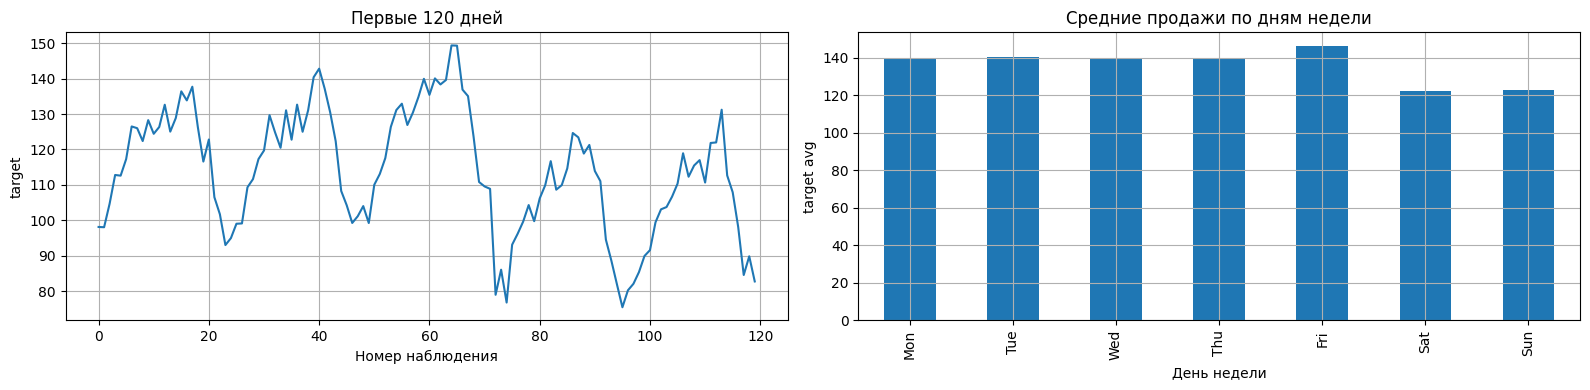

In [8]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Временной ряд: ежедневный спрос")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("target avg")

plt.tight_layout()
plt.show()

#### По дням недели - самый высокий таргет в пятницу, а самые низкие значения - в субботу и воскресенье. Видно тренд, что таргет с большим шумом увеличивался примерно ПОЧТИ линейно.

# Корректный temporal split

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


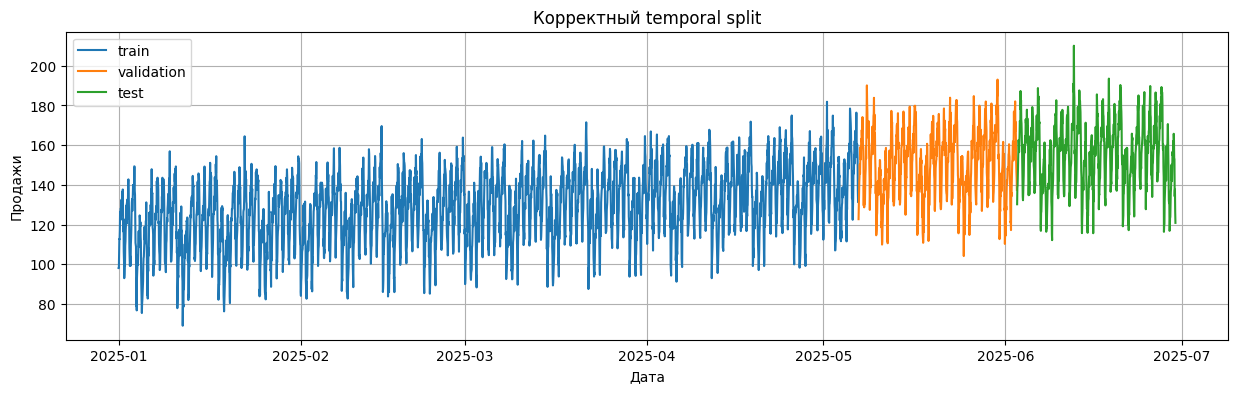

In [9]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.savefig(figures_dir / "series_split.png")
plt.show()

#### Если мы перемешаем наблюдения случайно, модель будет учиться на поздних датах и тестироваться на ранних. Для прогноза это нереалистично.

# Признаки для baseline-моделей

In [10]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,137.71,126.35,112.62,131.550000,4.907936


In [11]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", 
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7"
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)
print(len(val_feat))

Размерности:
X_train: (3014, 6) | y_train: (3014,)
X_val:   (646, 6) | y_val:   (646,)
X_test:  (646, 6) | y_test:  (646,)
646


# Оконное представление для GRU

In [12]:
# 1. Нормализация данных ТОЛЬКО по train набору (чтобы не было утечки информации)
scaler_GRU = StandardScaler()
train_scaled = scaler_GRU.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler_GRU.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler_GRU.transform(test_df[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое
def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train_GRU, y_train_GRU = make_windows(train_scaled, window_size)
X_val_GRU, y_val_GRU = make_windows(val_scaled, window_size)
X_test_GRU, y_test_GRU = make_windows(test_scaled, window_size)

print("X_train:", X_train_GRU.shape, "y_train:", y_train_GRU.shape)
print("X_val  :", X_val_GRU.shape, "y_val  :", y_val_GRU.shape)
print("X_test :", X_test_GRU.shape, "y_test :", y_test_GRU.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


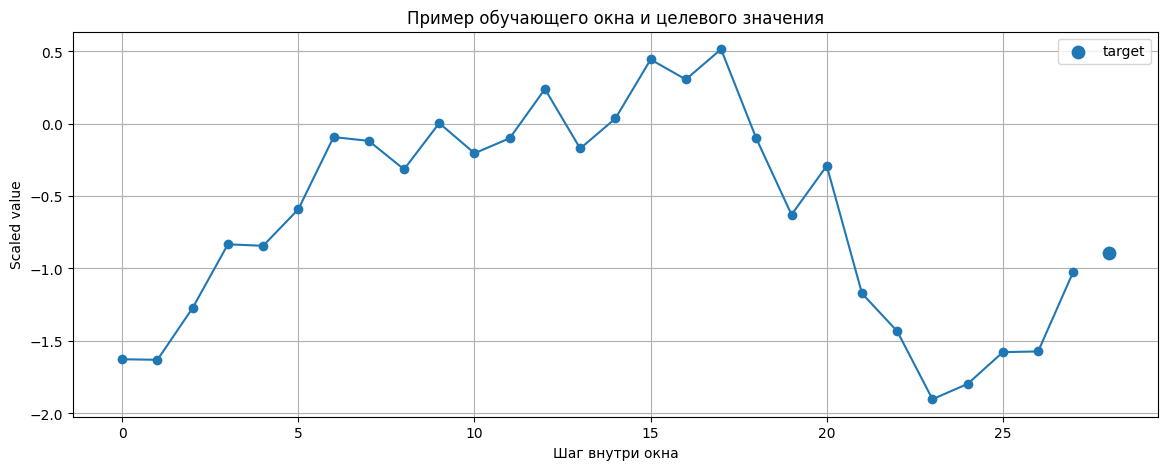

In [13]:
sample_idx = 0

print("Форма одного окна:", X_train_GRU[sample_idx].shape)
print("Первые 5 значений окна:", X_train_GRU[sample_idx][:5].ravel())
print("Цель:", y_train_GRU[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train_GRU[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train_GRU[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [14]:
# Определяем PyTorch Dataset для обработки последовательностей
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train_GRU, y_train_GRU)
val_ds = TimeSeriesDataset(X_val_GRU, y_val_GRU)
test_ds = TimeSeriesDataset(X_test_GRU, y_test_GRU)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


# Базовые функции обучения и оценки

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# Эксперименты

## B1

In [16]:
# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

# Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

naive_reg_val = evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)")
moving_reg_val = evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)")
ridge_reg_val = evaluate_regression(y_val, val_pred_ridge, "Ridge")

naive_reg_test = evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)")
moving_reg_test = evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)")
ridge_reg_test = evaluate_regression(y_test, test_pred_ridge, "Ridge")

## B2 - R1

In [17]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [18]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

## ТЕОРЕТИЧЕСКИ код написан так, что здесь не должно было быть leakage, но они могли бы быть, если бы использовался random_split, если бы будущие значения попадали в rolling_std или при fit_transform на всем ряде для GRU.

In [19]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.6994 | val_loss=0.6024
Epoch 02 | train_loss=0.2726 | val_loss=0.3549
Epoch 03 | train_loss=0.1632 | val_loss=0.2236
Epoch 04 | train_loss=0.1544 | val_loss=0.1980
Epoch 05 | train_loss=0.1512 | val_loss=0.1802
Epoch 06 | train_loss=0.1503 | val_loss=0.2615
Epoch 07 | train_loss=0.1463 | val_loss=0.2079
Epoch 08 | train_loss=0.1483 | val_loss=0.1745
Epoch 09 | train_loss=0.1463 | val_loss=0.3428
Epoch 10 | train_loss=0.1450 | val_loss=0.1793
Epoch 11 | train_loss=0.1419 | val_loss=0.2051
Epoch 12 | train_loss=0.1410 | val_loss=0.2272
Epoch 13 | train_loss=0.1373 | val_loss=0.2138
Epoch 14 | train_loss=0.1347 | val_loss=0.2043
Epoch 15 | train_loss=0.1305 | val_loss=0.2379
Epoch 16 | train_loss=0.1248 | val_loss=0.2244
Epoch 17 | train_loss=0.1172 | val_loss=0.1987
Epoch 18 | train_loss=0.1112 | val_loss=0.2192
Epoch 19 | train_loss=0.1129 | val_loss=0.1705
Epoch 20 | train_loss=0.1042 | val_loss=0.1719
Epoch 21 | train_loss=0.1053 | val_loss=0

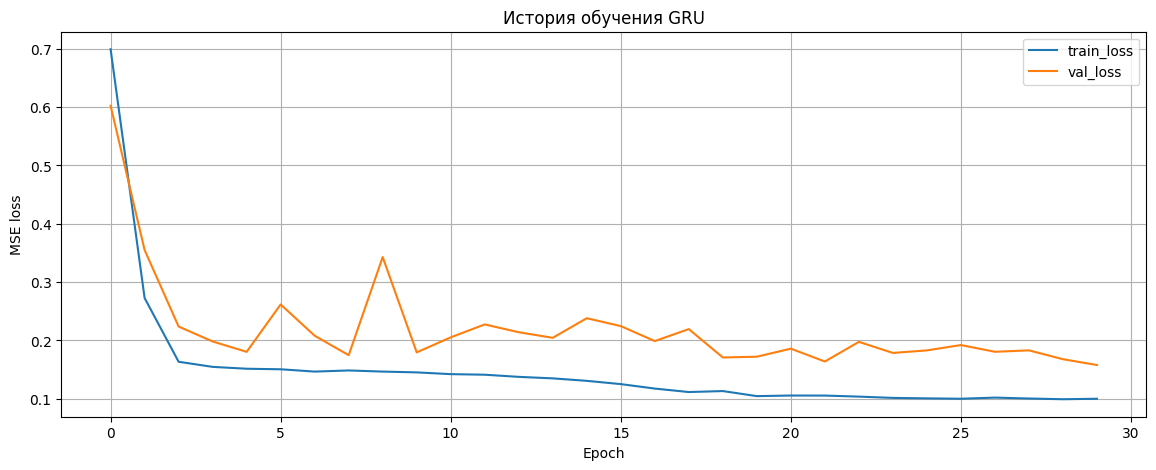

In [20]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig(figures_dir / "gru_learning_curves.png")
plt.show()

In [21]:
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_true = inverse_scale(gru_val_true_scaled, scaler_GRU)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler_GRU)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)}
    ]
)
tmp_path = artifacts_dir / 'best_gru.pt'
r1_blob = {
    "model_summary":"GRU-модель для временных рядов",
    "head":"nn.Linear",
    "window_size":28,
    "input_size":1,
    "hidden_size":64,
    "num_layers":2,
    "batch_size":64,
    "lr":5e-4,
    "epochs_trained":30,
    "dropout":0,
    "optimizer":"Adam",
    "dataset":DATASET,
    "seed":42,
    "scaler":"StandardScaler",
}
save_json(r1_blob, artifacts_dir / "best_gru_config.json")
torch.save(gru_model.state_dict(), tmp_path)

In [22]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

test_true = inverse_scale(gru_test_true_scaled, scaler_GRU)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler_GRU)

test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)}
    ]
)

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
    val_metrics,
], ignore_index=True)

print("Validation:")
display(baseline_results_val.sort_values("MAE"))
print("Для лучшей модели:")
display(test_metrics)

Validation:


,model,MAE,RMSE,MAPE
3,GRU,5.720356,7.372210,3.862717
0,Naive (lag_1),6.443406,8.203532,4.394594
2,Ridge,7.171741,8.723752,4.782421
1,MovingAverage(7),12.723717,15.236326,8.828779


Для лучшей модели:


,model,MAE,RMSE,MAPE
0,GRU,6.944059,8.805502,4.462556


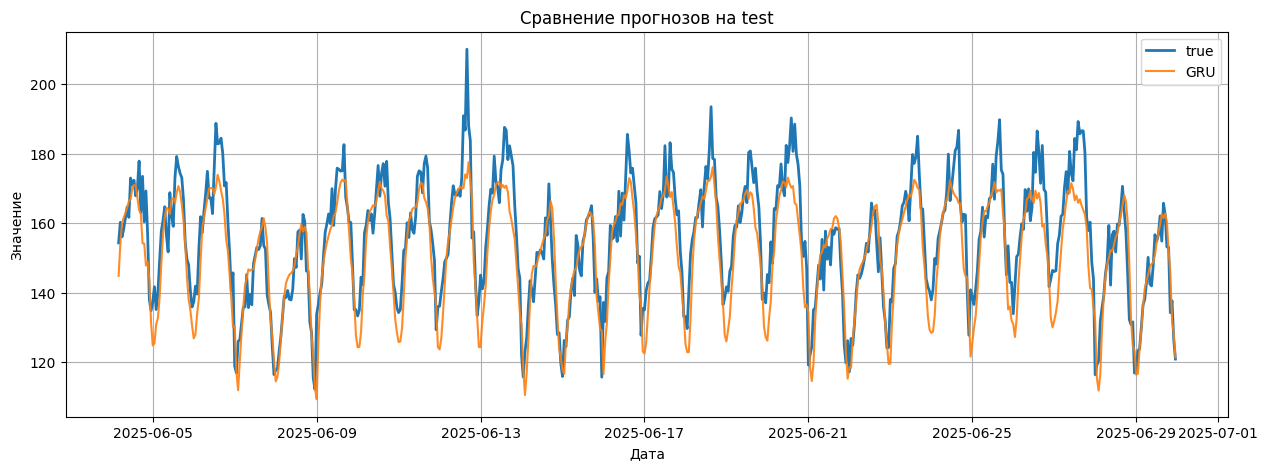

In [23]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_df["date"].iloc[window_size:].reset_index(drop=True), test_true, label="true", lw=2)
ax.plot(test_df["date"].iloc[window_size:].reset_index(drop=True), gru_test_pred, label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig(figures_dir / "best_forecast_test.png")
plt.show()

# Сравнение

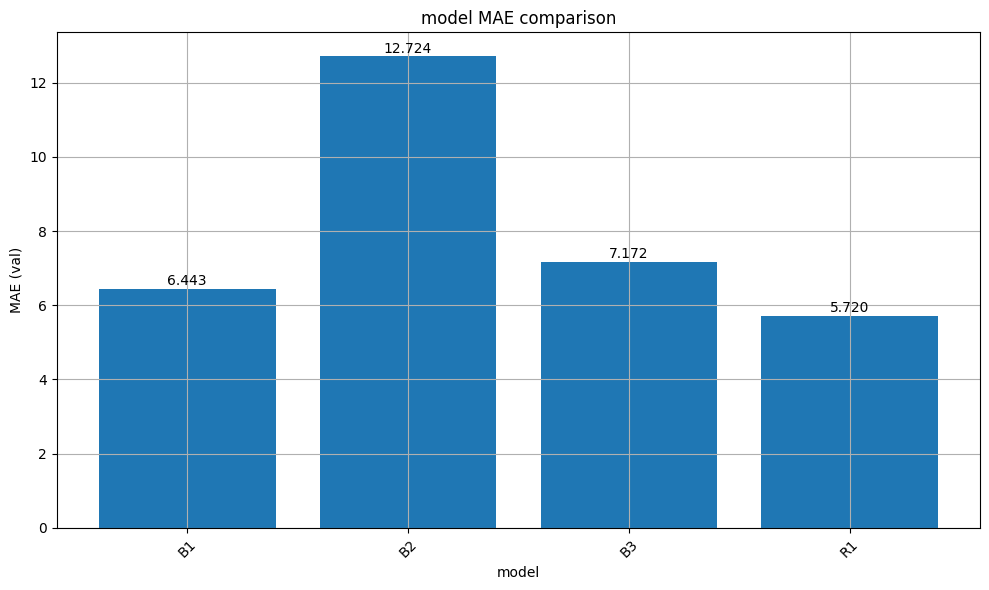

In [24]:
names = ["B1", "B2", "B3", "R1"]
plt.figure(figsize=(10, 6))
plt.bar(names, [i for i in baseline_results_val['MAE']])
plt.title('model MAE comparison')
plt.xlabel('model')
plt.ylabel('MAE (val)')
plt.xticks(rotation=45)
for i, v in enumerate([i for i in baseline_results_val['MAE']]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(figures_dir / "baselines_compare.png")
plt.show()

# Сохранение артефактов

In [25]:
eval_run(
    eid="B1",
    task="forecasting",
    dataset=DATASET,
    seed=42,
    split_summary="temporal-split 0.70/0.15/0.15 train/val/test",
    window_size=None,
    horizon=1,
    model_summary="baseline naive(lag_1)",
    features_summary="dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7",
    scaler=None,
    optimizer=None,
    lr=None,
    epochs_trained=None,
    best_val_mae=6.443406,
    best_val_rmse=8.203532,
    best_val_mape=4.394594,
    test_mae=None,
    test_rmse=None,
    test_mape=None,
    notes="для данной модели метрики на test не проверялись"
)
eval_run(
    eid="B2",
    task="forecasting",
    dataset=DATASET,
    seed=42,
    split_summary="temporal-split 0.70/0.15/0.15 train/val/test",
    window_size=None,
    horizon=1,
    model_summary="baseline moving-average(7)",
    features_summary="dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7",
    scaler=None,
    optimizer=None,
    lr=None,
    epochs_trained=None,
    best_val_mae=12.723717,
    best_val_rmse=15.236326,
    best_val_mape=8.828779,
    test_mae=None,
    test_rmse=None,
    test_mape=None,
    notes="для данной модели метрики на test не проверялись"
)
eval_run(
    eid="B3",
    task="forecasting",
    dataset=DATASET,
    seed=42,
    split_summary="temporal-split 0.70/0.15/0.15 train/val/test",
    window_size=None,
    horizon=1,
    model_summary="ridge-lag-features на лаговых, rolling и календарных признаках",
    features_summary="dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7",
    scaler="StandardScaler",
    optimizer=None,
    lr=None,
    epochs_trained=None,
    best_val_mae=7.171741,
    best_val_rmse=8.723752,
    best_val_mape=4.782421,
    test_mae=None,
    test_rmse=None,
    test_mape=None,
    notes="для данной модели метрики на test не проверялись"
)
eval_run(
    eid="R1",
    task="forecasting",
    dataset=DATASET,
    seed=42,
    split_summary="temporal-split 0.70/0.15/0.15 train/val/test",
    window_size=28,
    horizon=1,
    model_summary="gru-forecast",
    features_summary="dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7",
    scaler="StandardScaler",
    optimizer="Adam",
    lr=5e-4,
    epochs_trained=30,
    best_val_mae=5.720356,
    best_val_rmse=7.372210,
    best_val_mape=3.862717,
    test_mae=6.944059,
    test_rmse=8.805502,
    test_mape=4.462556,
    notes=""
)

In [26]:
print(runs)

[{'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42, 'split_summary': 'temporal-split 0.70/0.15/0.15 train/val/test', 'windows_size': None, 'horizon': 1, 'model_summary': 'baseline naive(lag_1)', 'features_summary': 'dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7', 'scaler': None, 'optimizer': None, 'lr': None, 'epochs_trained': None, 'best_val_mae': 6.443406, 'best_val_rmse': 8.203532, 'best_val_mape': 4.394594, 'test_mae': None, 'test_rmse': None, 'test_mape': None, 'notes': 'для данной модели метрики на test не проверялись'}, {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': 42, 'split_summary': 'temporal-split 0.70/0.15/0.15 train/val/test', 'windows_size': None, 'horizon': 1, 'model_summary': 'baseline moving-average(7)', 'features_summary': 'dayofweek, lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7', 'scaler': None, 'optimizer': None, 'lr': None, 'epochs_trained': None, 'best_val_ma

In [27]:
df_s = pd.DataFrame(runs)
display(df_s)
df_s.to_csv(artifacts_dir / "runs.csv", index=False)

,experiment_id,task,dataset,seed,split_summary,windows_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,temporal-split 0.70/0.15/0.15 train/val/test,NaN,1,baseline naive(lag_1),"dayofweek, lag_1, lag_7, lag_14, rolling_mean_...",NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,для данной модели метрики на test не проверялись
1,B2,forecasting,S12-hw-dataset.csv,42,temporal-split 0.70/0.15/0.15 train/val/test,NaN,1,baseline moving-average(7),"dayofweek, lag_1, lag_7, lag_14, rolling_mean_...",NaN,NaN,NaN,NaN,12.723717,15.236326,8.828779,NaN,NaN,NaN,для данной модели метрики на test не проверялись
2,B3,forecasting,S12-hw-dataset.csv,42,temporal-split 0.70/0.15/0.15 train/val/test,NaN,1,"ridge-lag-features на лаговых, rolling и кален...","dayofweek, lag_1, lag_7, lag_14, rolling_mean_...",StandardScaler,NaN,NaN,NaN,7.171741,8.723752,4.782421,NaN,NaN,NaN,для данной модели метрики на test не проверялись
3,R1,forecasting,S12-hw-dataset.csv,42,temporal-split 0.70/0.15/0.15 train/val/test,28.0,1,gru-forecast,"dayofweek, lag_1, lag_7, lag_14, rolling_mean_...",StandardScaler,Adam,0.0005,30.0,5.720356,7.372210,3.862717,6.944059,8.805502,4.462556,
